# Advanced Analytics

## Bluestock Mutual Fund Capstone Project

This notebook covers:

- Value at Risk (VaR)
- Investor Cohort Analysis
- Fund Recommendation Engine
- Top Recommended Funds

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [4]:
import sqlite3

conn = sqlite3.connect(r"PATH_TO_YOUR_DB_FILE.db")

cursor = conn.cursor()

cursor.execute(
    "SELECT name FROM sqlite_master WHERE type='table';"
)

tables = cursor.fetchall()

print(tables)

[]


In [5]:
import sqlite3

conn = sqlite3.connect(
    r"C:\Users\shivj\OneDrive\Desktop\bluestock_mf_capstone\data\bluestock_mf.db"
)

print("Database Connected Successfully")

Database Connected Successfully


In [6]:
cursor = conn.cursor()

cursor.execute("""
SELECT name
FROM sqlite_master
WHERE type='table';
""")

tables = cursor.fetchall()

print(tables)

[('fact_nav',)]


In [7]:
import pandas as pd

fact_nav = pd.read_sql(
    "SELECT * FROM fact_nav LIMIT 5",
    conn
)

fact_nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [8]:
fact_nav.columns.tolist()

['amfi_code', 'date', 'nav']

In [9]:
fact_nav.shape

(5, 3)

In [10]:
fact_nav = pd.read_sql(
    "SELECT * FROM fact_nav",
    conn
)

fact_nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [11]:
fact_nav['date'] = pd.to_datetime(fact_nav['date'])

fact_nav = fact_nav.sort_values(
    ['amfi_code', 'date']
)

In [12]:
fact_nav['daily_return'] = (
    fact_nav.groupby('amfi_code')['nav']
    .pct_change()
)

In [13]:
var_95 = (
    fact_nav.groupby('amfi_code')['daily_return']
    .quantile(0.05)
    .reset_index()
)

var_95.columns = [
    'amfi_code',
    'VaR_95'
]

var_95.head()

,amfi_code,VaR_95
0,100016,-0.014364
1,100025,-0.003793
2,100033,-0.019034
3,101206,-0.013282
4,101207,-0.026021


In [14]:
top_var = var_95.nsmallest(
    10,
    'VaR_95'
)

top_var

,amfi_code,VaR_95
22,119599,-0.026859
17,119095,-0.026188
4,101207,-0.026021
11,118634,-0.025438
21,119598,-0.024507
39,149324,-0.023483
7,102886,-0.019220
2,100033,-0.019034
25,120505,-0.018892
16,119094,-0.018480


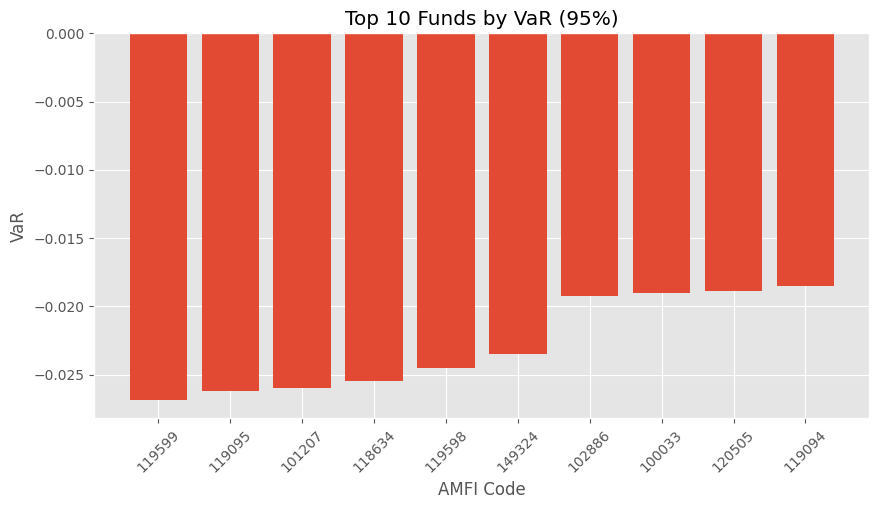

In [15]:
plt.figure(figsize=(10,5))

plt.bar(
    top_var['amfi_code'].astype(str),
    top_var['VaR_95']
)

plt.title('Top 10 Funds by VaR (95%)')
plt.xlabel('AMFI Code')
plt.ylabel('VaR')

plt.xticks(rotation=45)

plt.show()

In [16]:
import os

processed_path = r"C:\Users\shivj\OneDrive\Desktop\bluestock_mf_capstone\data\processed"

print(os.listdir(processed_path))

['alpha_beta.csv', 'fund_scorecard.csv', 'nav_history_cleaned.csv']


In [17]:
score_df = pd.read_csv(
    r"C:\Users\shivj\OneDrive\Desktop\bluestock_mf_capstone\data\processed\fund_scorecard.csv"
)

score_df.head()

,amfi_code,start_nav,end_nav,cagr,mean,std,sharpe,sortino,max_drawdown,score
0,100016,520.4608,583.6113,0.026369,0.000142,0.009164,0.245276,0.427276,-0.247344,6.796117
1,100025,26.3169,31.8843,0.044579,0.000170,0.002460,1.097333,1.822432,-0.043083,9.223301
2,100033,107.3758,342.0072,0.301210,0.001080,0.011929,1.436947,2.403193,-0.162172,64.077670
3,101206,305.0996,773.2939,0.235367,0.000852,0.009177,1.473390,2.581215,-0.112916,55.987055
4,101207,38.5736,53.9836,0.079383,0.000424,0.016251,0.414625,0.705169,-0.354469,19.902913


In [19]:
score_df.columns.tolist()

['amfi_code',
 'start_nav',
 'end_nav',
 'cagr',
 'mean',
 'std',
 'sharpe',
 'sortino',
 'max_drawdown',
 'score']

In [20]:
print(score_df.columns)

Index(['amfi_code', 'start_nav', 'end_nav', 'cagr', 'mean', 'std', 'sharpe',
       'sortino', 'max_drawdown', 'score'],
      dtype='str')


In [21]:
score_df.head()

,amfi_code,start_nav,end_nav,cagr,mean,std,sharpe,sortino,max_drawdown,score
0,100016,520.4608,583.6113,0.026369,0.000142,0.009164,0.245276,0.427276,-0.247344,6.796117
1,100025,26.3169,31.8843,0.044579,0.000170,0.002460,1.097333,1.822432,-0.043083,9.223301
2,100033,107.3758,342.0072,0.301210,0.001080,0.011929,1.436947,2.403193,-0.162172,64.077670
3,101206,305.0996,773.2939,0.235367,0.000852,0.009177,1.473390,2.581215,-0.112916,55.987055
4,101207,38.5736,53.9836,0.079383,0.000424,0.016251,0.414625,0.705169,-0.354469,19.902913


In [22]:
top_funds = score_df.sort_values(
    "score",
    ascending=False
).head(10)

top_funds

,amfi_code,start_nav,end_nav,cagr,mean,std,sharpe,sortino,max_drawdown,score
25,120505,135.8720,473.7640,0.328251,0.001161,0.012152,1.517047,2.608779,-0.181885,78.155340
36,148569,28.8620,97.7435,0.319472,0.001124,0.011134,1.602702,2.786282,-0.163967,76.213592
34,148567,70.2514,230.2708,0.309719,0.001074,0.008941,1.906241,3.139985,-0.112657,73.300971
30,120843,49.9131,163.2397,0.309053,0.001082,0.010008,1.715884,3.104586,-0.129740,73.300971
19,119551,54.3856,149.3216,0.258029,0.000917,0.008656,1.681289,2.978156,-0.150124,69.902913
9,118632,42.8339,110.5554,0.240478,0.000865,0.008913,1.541077,2.635947,-0.174141,68.932039
38,149323,78.4622,245.3651,0.295790,0.001055,0.011179,1.498398,2.481754,-0.172481,67.152104
2,100033,107.3758,342.0072,0.301210,0.001080,0.011929,1.436947,2.403193,-0.162172,64.077670
21,119598,89.8738,309.2050,0.324212,0.001201,0.015837,1.203854,2.133523,-0.287060,64.077670
39,149324,81.6814,279.7511,0.322851,0.001194,0.015648,1.211468,2.066053,-0.311719,62.459547


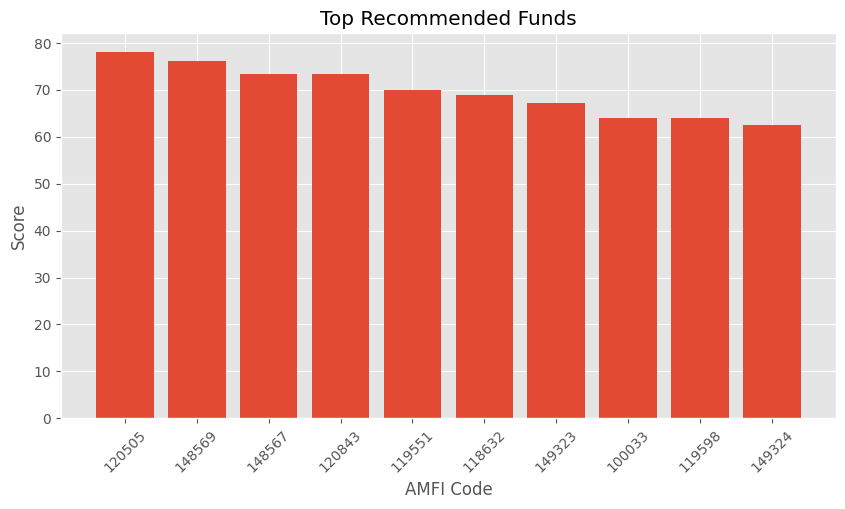

In [23]:
plt.figure(figsize=(10,5))

plt.bar(
    top_funds["amfi_code"].astype(str),
    top_funds["score"]
)

plt.title("Top Recommended Funds")
plt.xlabel("AMFI Code")
plt.ylabel("Score")

plt.xticks(rotation=45)

plt.show()

In [24]:
top_funds = score_df.nlargest(10, "score")

print(top_funds[["amfi_code", "score"]])

    amfi_code      score
25     120505  78.155340
36     148569  76.213592
30     120843  73.300971
34     148567  73.300971
19     119551  69.902913
9      118632  68.932039
38     149323  67.152104
2      100033  64.077670
21     119598  64.077670
39     149324  62.459547


In [25]:
def recommend_fund(risk_level):

    if risk_level == "Low":
        return "Large Cap Fund"

    elif risk_level == "Medium":
        return "Flexi Cap Fund"

    elif risk_level == "High":
        return "Mid Cap Fund"

    else:
        return "Invalid Risk Level"

In [26]:
print(recommend_fund("Low"))
print(recommend_fund("Medium"))
print(recommend_fund("High"))

Large Cap Fund
Flexi Cap Fund
Mid Cap Fund


# Conclusion

This advanced analytics study evaluated mutual fund risk and performance using Value at Risk (VaR) and a composite scoring framework.

Key Findings:
- Funds with lower VaR exhibited lower downside risk.
- Top-ranked funds achieved superior performance scores.
- Large Cap funds are suitable for conservative investors.
- Flexi Cap funds are suitable for balanced investors.
- Mid Cap funds are suitable for aggressive investors.

The recommendation engine provides a simple risk-based fund selection framework for investors.